# Preprocesamiento y Limpieza

Limpieza del dataset `nlp-getting-started` (Natural Language Processing with Disaster Tweets). Se aplicarán las siguientes tareas en orden:
1. Convertir texto a minúsculas.
2. Eliminar URLs.
3. Quitar caracteres especiales (`#`, `@`, `'`).
4. Quitar emoticones.
5. Quitar signos de puntuación.
6. Quitar números.
7. Quitar stopwords (usando nltk).

In [1]:
import sys
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Añadir el directorio principal al path para importar src
sys.path.append('..')
from src.limpieza import apply_cleaning_pipeline

# Configuración de rutas
raw_path = Path("../data/raw/train.csv")
prep_dir = Path("../data/preprocessing")
clean_dir = Path("../data/cleaned")

clean_dir.mkdir(parents=True, exist_ok=True)


In [2]:
if not raw_path.exists():
    raise FileNotFoundError(f"No se encontró {raw_path}. Por favor verifique la descarga.")

df = pd.read_csv(raw_path)
display(df.head())


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## Ejecución del Pipeline

In [3]:
# Aplicar pipeline y guardar pasos intermedios
df_cleaned, stats = apply_cleaning_pipeline(df, text_col='text', preprocessing_dir=prep_dir)

# Guardar resultado final
final_path = clean_dir / "train_cleaned.csv"
df_cleaned.to_csv(final_path, index=False)

print(f"Limpieza completada. Datos guardados en {final_path}")
display(df_cleaned.head())


Limpieza completada. Datos guardados en ../data/cleaned/train_cleaned.csv


,id,keyword,location,text,target
0,1,NaN,NaN,deeds reason earthquake may allah forgive us,1
1,4,NaN,NaN,forest fire near la ronge sask canada,1
2,5,NaN,NaN,residents asked shelter place notified officer...,1
3,6,NaN,NaN,people receive wildfires evacuation orders cal...,1
4,7,NaN,NaN,got sent photo ruby alaska smoke wildfires pou...,1


## Visualización: Longitud Promedio del Texto por Paso

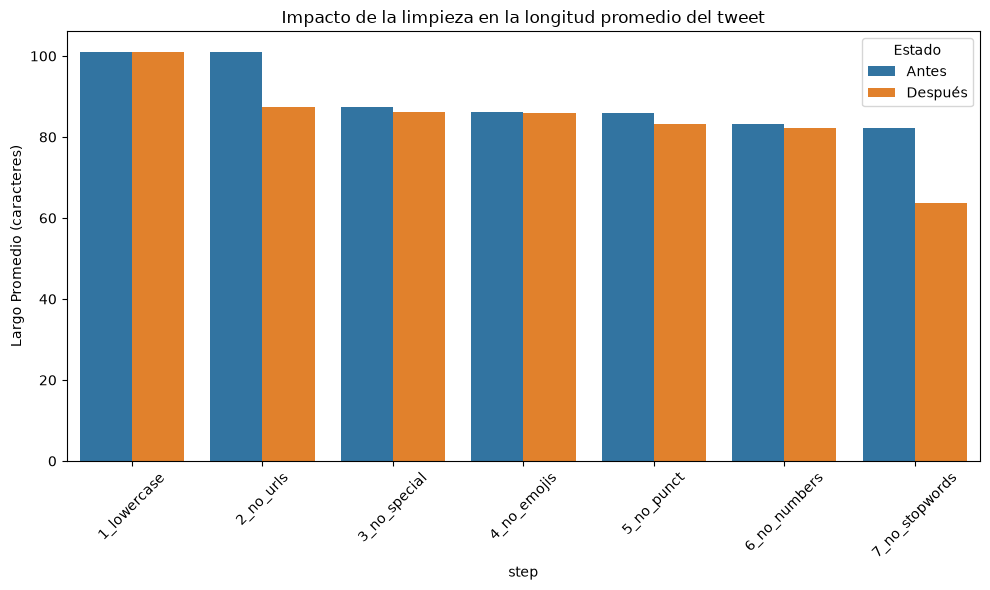

,step,len_before,len_after
0,1_lowercase,101.037436,101.037436
1,2_no_urls,101.037436,87.322869
2,3_no_special,87.322869,86.100092
3,4_no_emojis,86.100092,85.806909
4,5_no_punct,85.806909,83.298043
5,6_no_numbers,83.298043,82.272429
6,7_no_stopwords,82.272429,63.815185


In [4]:
# Preparamos datos para la gráfica
plot_data = pd.melt(stats, id_vars=['step'], value_vars=['len_before', 'len_after'], 
                    var_name='Estado', value_name='Largo Promedio (caracteres)')
plot_data['Estado'] = plot_data['Estado'].map({'len_before': 'Antes', 'len_after': 'Después'})

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='step', y='Largo Promedio (caracteres)', hue='Estado')
plt.title("Impacto de la limpieza en la longitud promedio del tweet")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(stats)
